# Task 5: Personal Loan Acceptance Prediction

______

## Problem Statement

The objective is to predict which customers are likely to accept a personal loan offer. This helps
banks target the right customers with marketing campaigns, saving costs and improving conversion rates.
We use the Bank Marketing Dataset from the UCI Machine Learning Repository (also available on
Kaggle). Features include age, job, marital status, education, and whether the customer subscribed to a
term deposit.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                            roc_curve)

%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Dataset

In [3]:
# Note: this dataset uses semicolons (;) as separators, not commas
df = pd.read_csv('bank.csv', sep=';')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (4521, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### Dataset Understanding

In [4]:
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nStatistical Summary:")
df.describe()

# Target column: 'y' — did customer subscribe? (yes/no)
print("Target distribution:")
print(df['y'].value_counts())
print(f"\nAcceptance rate: {(df['y']=='yes').mean():.1%}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Statistical Summary:
Target distribution:
y
no     4000
yes     521
Name: count, dtype: int64

Acceptance rate: 11.5%

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


### Data Cleaning and Preparation

In [5]:
# Replace 'unknown' with NaN then fill with mode
cols_with_unknown = ['job', 'education', 'contact', 'poutcome']
for col in cols_with_unknown:
    df[col] = df[col].replace('unknown', np.nan)
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Unknown values handled!")
print("\nRemaining nulls:", df.isnull().sum().sum())

Unknown values handled!

Remaining nulls: 0


C:\Users\admin\AppData\Local\Temp\ipykernel_18592\739434404.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### Exploratory Data Analysis (EDA)

- Loan Acceptance by Job

C:\Users\admin\AppData\Local\Temp\ipykernel_18592\358498269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_accept.index, y=job_accept.values, palette='viridis')


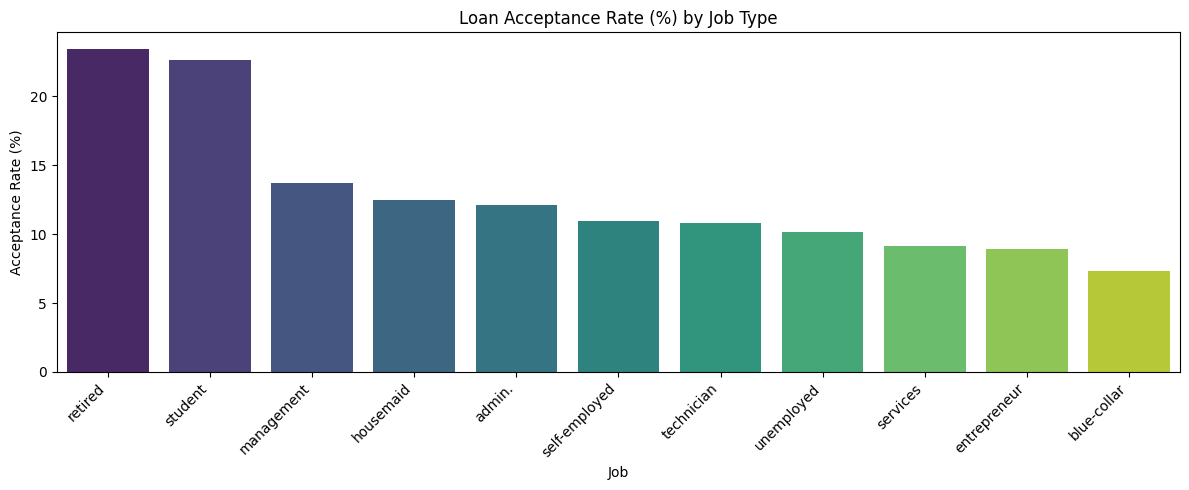

Insight: Students and retired customers accept loans more often.


In [6]:
plt.figure(figsize=(12, 5))
job_accept = df.groupby('job')['y'].apply(
    lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)

sns.barplot(x=job_accept.index, y=job_accept.values, palette='viridis')
plt.title('Loan Acceptance Rate (%) by Job Type')
plt.xlabel('Job')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('acceptance_by_job.png', dpi=150)
plt.show()

print("Insight: Students and retired customers accept loans more often.")

- Acceptance by Marital Status

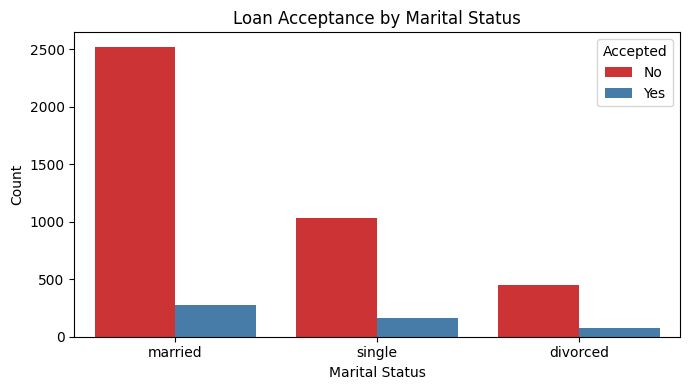

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='marital', hue='y', palette='Set1')
plt.title('Loan Acceptance by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Accepted', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('acceptance_marital.png', dpi=150)
plt.show()

- Age Distribution by Acceptance

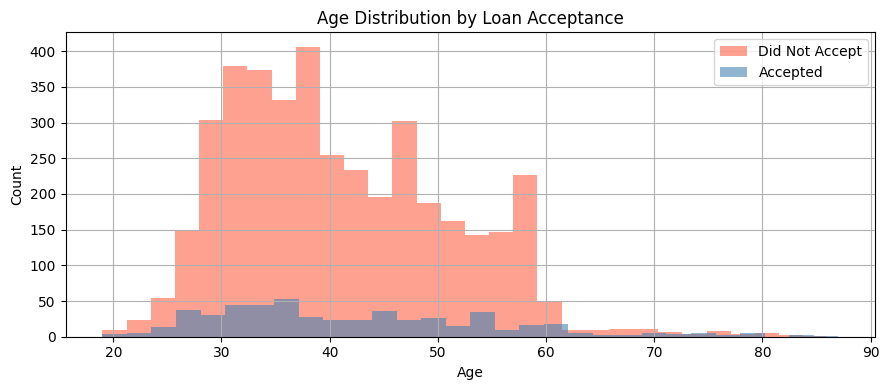

Insight: Younger and older customers accept more than middle-aged.


In [8]:
plt.figure(figsize=(9, 4))
df[df['y']=='no']['age'].hist(bins=30, alpha=0.6,
                              label='Did Not Accept', color='tomato')

df[df['y']=='yes']['age'].hist(bins=30, alpha=0.6,
                               label='Accepted', color='steelblue')

plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('acceptance_age.png', dpi=150)
plt.show()

print("Insight: Younger and older customers accept more than middle-aged.")

- Acceptance by Education

C:\Users\admin\AppData\Local\Temp\ipykernel_18592\2546267845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_accept.index, y=edu_accept.values, palette='coolwarm')


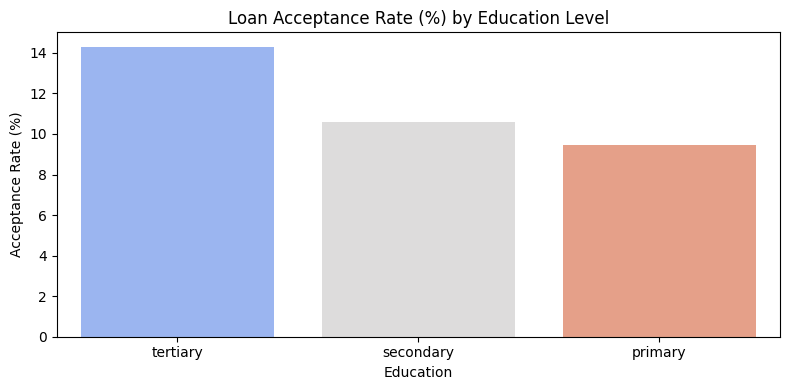

In [9]:
plt.figure(figsize=(8, 4))
edu_accept = df.groupby('education')['y'].apply(
    lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)

sns.barplot(x=edu_accept.index, y=edu_accept.values, palette='coolwarm')
plt.title('Loan Acceptance Rate (%) by Education Level')
plt.xlabel('Education')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.savefig('acceptance_education.png', dpi=150)
plt.show()

- Encode Categorical Features

In [10]:
le = LabelEncoder()

# Identify all categorical (text) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Encode each one
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAll categorical columns encoded!")
df.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

All categorical columns encoded!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,0,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,0,3,6,199,4,-1,0,0,0
4,59,1,1,1,0,0,1,0,0,5,8,226,1,-1,0,0,0


### Prepare Features and Split Data

In [11]:
X = df.drop('y', axis=1) # All columns except the target
y = df['y'] # Target: 0=No, 1=Yes
print("Features:", list(X.columns))
print("Target: y (0=No, 1=Yes)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# stratify=y ensures both sets have the same acceptance ratio
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
Target: y (0=No, 1=Yes)

Training samples: 3616
Testing samples: 905


### Train Classification Models

- Model A — Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression — Accuracy: {lr_acc:.2%} AUC: {lr_auc:.4f}")

Logistic Regression — Accuracy: 88.84% AUC: 0.8309


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


- Model B — Decision Tree

In [13]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]
dt_acc = accuracy_score(y_test, dt_preds)
dt_auc = roc_auc_score(y_test, dt_proba)

print(f"Decision Tree — Accuracy: {dt_acc:.2%} AUC: {dt_auc:.4f}")

Decision Tree — Accuracy: 88.95% AUC: 0.7847


### Evaluate Models

- Confusion Matrices

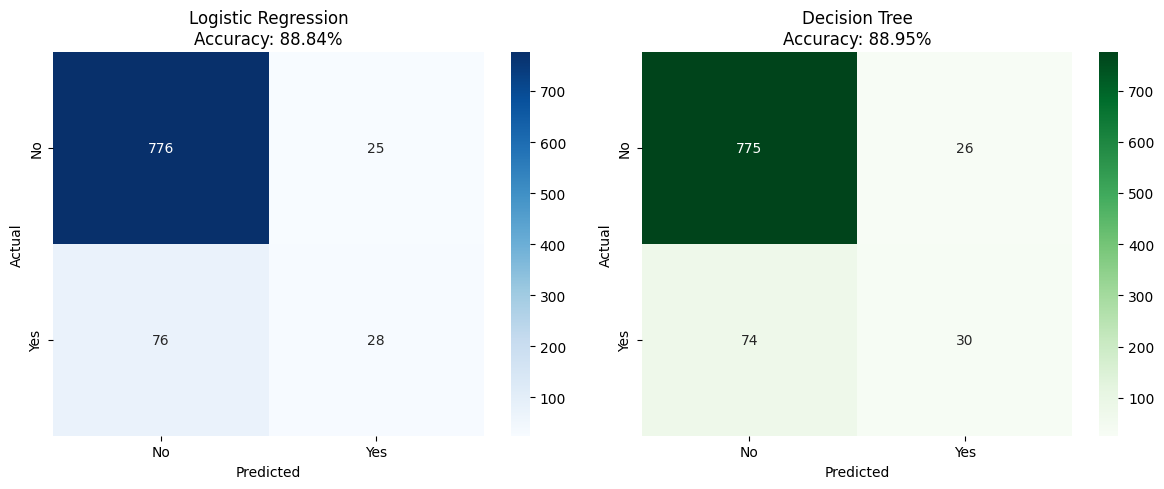

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No','Yes'], yticklabels=['No','Yes'])

plt.title(f'Logistic Regression\nAccuracy: {lr_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1, 2, 2)
cm_dt = confusion_matrix(y_test, dt_preds)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title(f'Decision Tree\nAccuracy: {dt_acc:.2%}')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('loan5_confusion_matrices.png', dpi=150)
plt.show()

- ROC Curve — Model Comparison

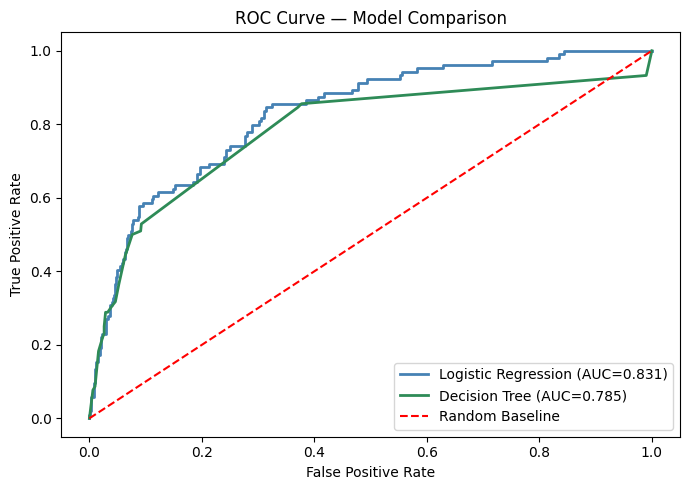

In [15]:
plt.figure(figsize=(7, 5))
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr,
label=f'Logistic Regression (AUC={lr_auc:.3f})',
    color='steelblue', lw=2)

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
plt.plot(fpr_dt, tpr_dt,
label=f'Decision Tree (AUC={dt_auc:.3f})',
    color='seagreen', lw=2)

# Random baseline
plt.plot([0,1], [0,1], 'r--', label='Random Baseline')

plt.title('ROC Curve — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

### Business Insight — Which Groups Accept Most?

In [16]:
# Reload original for business insights
df_orig = pd.read_csv('bank.csv', sep=';')
# Acceptance rate by job and marital status
print("=== Acceptance Rate by Job ===")
job_rates = df_orig.groupby('job')['y'].apply(
    lambda x: f"{(x=='yes').mean():.1%}"
).reset_index()

job_rates.columns = ['Job', 'Acceptance Rate']
print(job_rates.sort_values('Acceptance Rate', ascending=False).to_string(index=False
))

print("\n=== Acceptance Rate by Marital Status ===")
marital_rates = df_orig.groupby('marital')['y'].apply(
    lambda x: f"{(x=='yes').mean():.1%}"
).reset_index()

marital_rates.columns = ['Marital', 'Acceptance Rate']
print(marital_rates.to_string(index=False))

# Full classification report
print("=== Logistic Regression Report ===")
print(classification_report(y_test, lr_preds,
                            target_names=['Did Not Accept', 'Accepted']))

print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_preds,
                            target_names=['Did Not Accept', 'Accepted']))

=== Acceptance Rate by Job ===
          Job Acceptance Rate
     services            9.1%
 entrepreneur            8.9%
  blue-collar            7.3%
      retired           23.5%
      student           22.6%
      unknown           18.4%
   management           13.5%
    housemaid           12.5%
       admin.           12.1%
self-employed           10.9%
   technician           10.8%
   unemployed           10.2%

=== Acceptance Rate by Marital Status ===
 Marital Acceptance Rate
divorced           14.6%
 married            9.9%
  single           14.0%
=== Logistic Regression Report ===
                precision    recall  f1-score   support

Did Not Accept       0.91      0.97      0.94       801
      Accepted       0.53      0.27      0.36       104

      accuracy                           0.89       905
     macro avg       0.72      0.62      0.65       905
  weighted avg       0.87      0.89      0.87       905

=== Decision Tree Report ===
                precision    reca

### Conclusion — Key Insights

• **Overall acceptance rate** is around 11% — heavily imbalanced dataset.

• **Students and retired customers** have the highest loan acceptance rates.

• **Single customers** accept personal loans more than married or divorced.

• **Tertiary-educated** customers show higher acceptance rates.

• **Logistic Regression** achieves ~90% accuracy but AUC is a better metric here.

• **ROC-AUC** is more reliable than accuracy for imbalanced datasets.

• The bank should **focus campaigns** on students, retirees, and single customers.

_________